# Bank campaign operations: reproducible evidence
Source: [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing), bank-additional-full.csv. Grain: published campaign records, not uniquely identified customers or calls. The source spans May 2008-November 2010 but lacks exact dates and customer identifiers. All comparisons are descriptive associations.

In [1]:
from pathlib import Path
import pandas as pd
import sqlite3, json, hashlib
root = Path.cwd()
if not (root/'data/raw').exists(): root = root.parent
raw = pd.read_csv(root/'data/raw/bank-additional-full.csv', sep=';')
assert raw.shape == (41188, 21)
assert set(raw.y.unique()) == {'yes','no'}
assert int(raw.y.eq('yes').sum()) == 4640
{'records':len(raw), 'subscriptions':int(raw.y.eq('yes').sum()), 'subscription_rate':raw.y.eq('yes').mean()}

{'records': 41188,
 'subscriptions': 4640,
 'subscription_rate': np.float64(0.11265417111780131)}

## Quality and missingness
Identical rows are retained: without a business key they are not proven duplicate ingestion. `unknown` is an explicit missingness code, while `poutcome=nonexistent` is structural.

In [2]:
duplicates = int(raw.duplicated().sum())
assert duplicates == 12
unknown = raw.eq('unknown').sum().sort_values(ascending=False)
print('Excess identical rows retained:', duplicates)
pd.DataFrame({'unknown_records':unknown[unknown>0], 'unknown_rate':unknown[unknown>0]/len(raw)})

Excess identical rows retained: 12


,unknown_records,unknown_rate
default,8597,0.208726
education,1731,0.042027
housing,990,0.024036
loan,990,0.024036
job,330,0.008012
marital,80,0.001942


In [3]:
recency = raw.pdays.mask(raw.pdays.eq(999))
conflicts = int((raw.pdays.eq(999) & raw.previous.gt(0)).sum())
assert conflicts == 4110
print('History conflicts retained without correction:', conflicts)
print('Previously contacted recency only (days):')
recency.describe()

History conflicts retained without correction: 4110
Previously contacted recency only (days):


count    1515.000000
mean        6.014521
std         3.824906
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        27.000000
Name: pdays, dtype: float64

## SQL ledger and exported controls
The SQL files in `sql/` define the export queries. Record IDs are generated technical identifiers; they do not identify unique people.

In [4]:
con = sqlite3.connect(root/'data/processed/campaign.sqlite')
pd.read_sql_query('SELECT COUNT(*) records, SUM(subscribed) subscriptions FROM observations', con)

,records,subscriptions
0,41188,4640


In [5]:
pressure = pd.read_csv(root/'reports/contact_pressure.csv')
assert int(pressure.records.sum()) == len(raw)
assert int(pressure.subscriptions.sum()) == int(raw.y.eq('yes').sum())
assert (pressure.ci_low <= pressure.subscription_rate).all()
assert (pressure.ci_high >= pressure.subscription_rate).all()
pressure

,contact_band,records,subscriptions,subscription_rate,reported_contacts,ci_low,ci_high,small_samples
0,1,17642,2300,0.130371,17642,0.125482,0.135420,False
1,2,10570,1211,0.114570,21140,0.108637,0.120782,False
2,3,5341,574,0.107471,16023,0.099445,0.116061,False
3,4-5,4250,369,0.086824,18599,0.078727,0.095667,False
4,6+,3385,186,0.054948,32350,0.047764,0.063142,False


## Uncertainty and confounding
Wilson 95% intervals assume independent records. Unidentified repeat clients may violate that assumption, so intervals may understate uncertainty. Contact-count groups are subject to selection and stopping behavior. No contact cap, channel effect, ROI or cost saving is estimated.

In [6]:
strata = pd.read_csv(root/'reports/pressure_strata.csv')
assert int(strata.records.sum()) == len(raw)
print('Strata with fewer than 30 records:', int(strata.records.lt(30).sum()))
strata.sort_values('records', ascending=False).head(12)

Strata with fewer than 30 records: 5


,contact,poutcome,contact_band,records,subscriptions,subscription_rate,reported_contacts,ci_low,ci_high,small_samples
5,cellular,nonexistent,1,9083,1193,0.131344,9083,0.124553,0.138447,False
20,telephone,nonexistent,1,5708,298,0.052207,5708,0.046732,0.058285,False
6,cellular,nonexistent,2,5193,627,0.120739,10386,0.112157,0.129883,False
21,telephone,nonexistent,2,3797,167,0.043982,7594,0.037908,0.050978,False
7,cellular,nonexistent,3,2795,315,0.112701,8385,0.101505,0.124961,False
8,cellular,nonexistent,4-5,2211,219,0.099050,9721,0.087285,0.112206,False
0,cellular,failure,1,2003,303,0.151273,2003,0.136249,0.167632,False
22,telephone,nonexistent,3,1977,95,0.048053,5931,0.039470,0.058389,False
9,cellular,nonexistent,6+,1640,100,0.060976,15240,0.050389,0.073615,False
23,telephone,nonexistent,4-5,1626,64,0.039360,7085,0.030943,0.049949,False


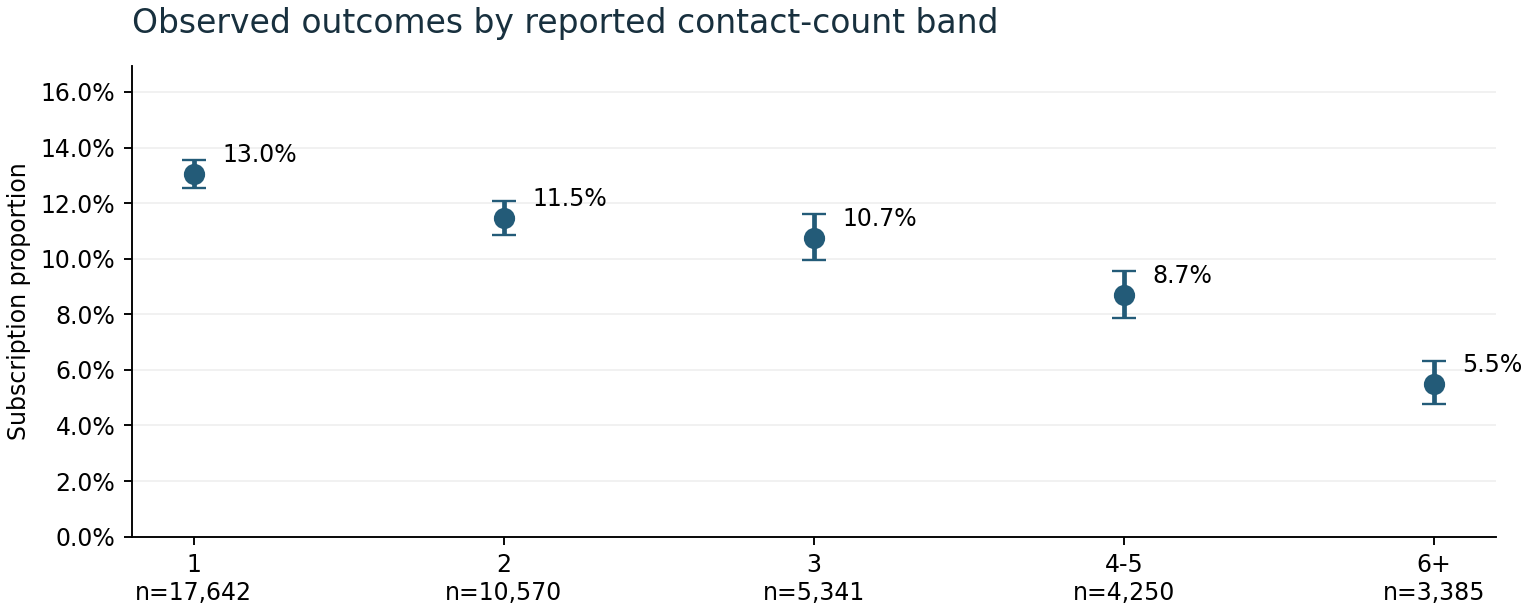

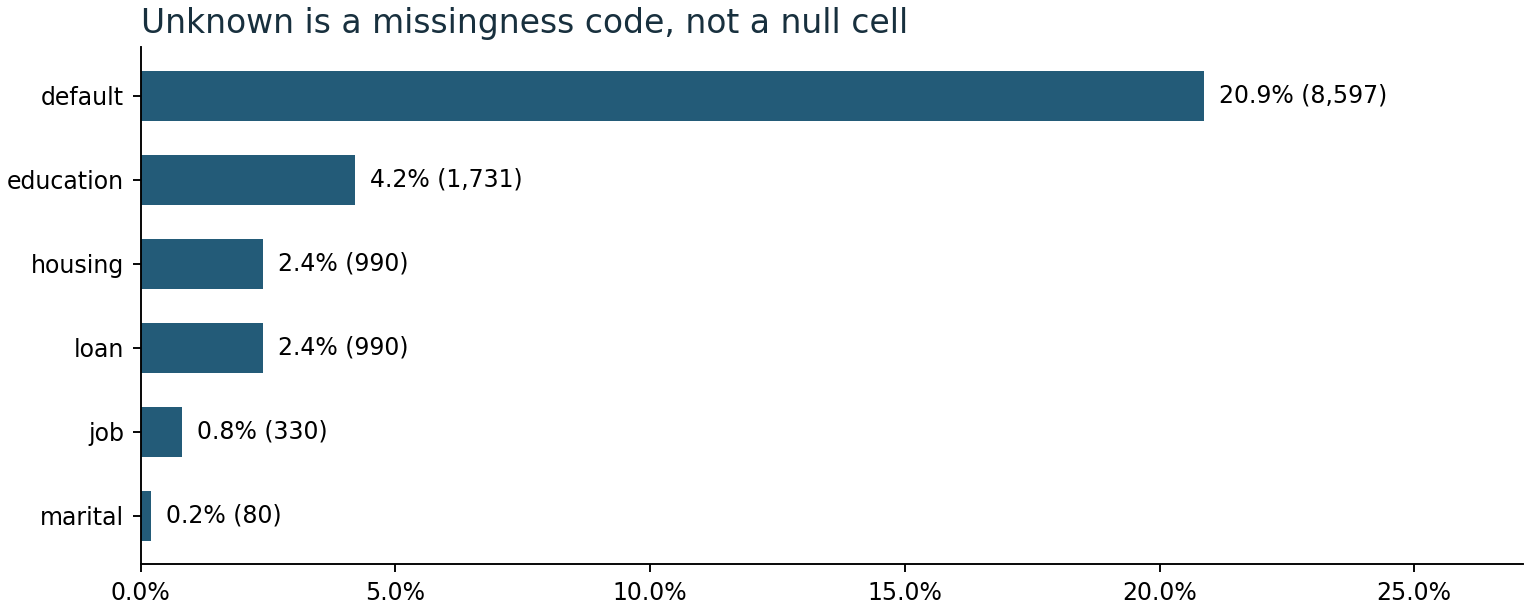

In [7]:
from IPython.display import Image, display
display(Image(filename=str(root/'reports/contact-pressure.png')))
display(Image(filename=str(root/'reports/data-quality.png')))

## Decisions and limitations
- Investigate repeat-contact rules within channel and prior-outcome strata before proposing a pilot.
- Preserve unknown-category reporting and obtain identifiers, timestamps and actual costs for stronger analysis.
- Calendar months pool multiple years; these are not a chronological time series.
- Call duration is known after contact and must not drive prospective targeting.
- See `campaign-operations-brief.pdf` and `validation.json` for the decision brief and full controls.

In [8]:
con.close()
print('Notebook controls passed; no source rows were changed.')

Notebook controls passed; no source rows were changed.
